# leg_RAG — Chunking & Embeddings EDA

A close look at `retrieval/chunk.py` and `retrieval/embed.py`'s output: what
the chunks actually look like, how much consecutive chunks overlap, what
gets replaced before embedding, and what the embedding vectors themselves
look like (dimensionality, normalization, nearest-neighbor structure).

Run from the project root so `import config` resolves — this notebook finds
it automatically by walking upward, so it's safe to move.

In [1]:
import csv
import json
import sys
import random
import statistics
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
import chromadb

_search = Path.cwd()
while not (_search / "config.py").exists():
    if _search.parent == _search:
        raise RuntimeError("Could not find project root (config.py) — open this notebook from within the leg_RAG project.")
    _search = _search.parent
PROJECT_ROOT = _search
sys.path.insert(0, str(PROJECT_ROOT))
import config
assert hasattr(config, "PROCESSED_DIR"), "Imported the wrong 'config' module — check for a stray pip package named 'config'."

csv.field_size_limit(min(sys.maxsize, 2**31 - 1))
plt.rcParams["figure.figsize"] = (9, 4)
encoding = tiktoken.encoding_for_model(config.EMBEDDING_MODEL)

## 1. The chunking method (recap)

From `retrieval/chunk.py`:

- The raw `plain_text` is PDF-derived and uses double-newlines as generic
  *line* breaks (not real paragraph markers), plus page-number lines and
  form-feed page-break characters — cleaned into continuous prose first.
- Split by **real token count** (via `tiktoken`, matching how
  `text-embedding-3-small` actually counts tokens) into ~300-token chunks,
  not a word-count approximation.
- **50-token overlap** between consecutive chunks of the same opinion, so a
  sentence that would otherwise get cut in half by a chunk boundary usually
  survives intact in at least one chunk.
- Chunk boundaries are **snapped to never land inside a citation** — if the
  natural 300-token cutoff would slice through the middle of e.g.
  "486 F.3d 572", the boundary gets pushed out to the end of that citation
  instead.
- A separate `embedding_text` field replaces each citation's literal text
  with a `[CITATION]` placeholder before embedding (see section 4) — keeps
  embeddings from being dominated by dense-but-semantically-flat citation
  strings, while the original `text` field (with real citations) is what
  gets shown to a human/LLM.

## 2. Load chunks & basic stats

In [2]:
with open(config.PROCESSED_DIR / "chunks_loose.jsonl", encoding="utf-8") as f:
    chunks = [json.loads(line) for line in f]

chunks_df = pd.DataFrame(chunks)
chunks_df["char_len"] = chunks_df["text"].str.len()
chunks_df["token_len"] = chunks_df["text"].apply(lambda t: len(encoding.encode(t)))

print(f"{len(chunks_df)} chunks from {chunks_df['opinion_id'].nunique()} opinions.")
chunks_df[["chunk_id", "opinion_id", "case_name", "char_span", "char_len", "token_len"]].head()

37081 chunks from 1696 opinions.


,chunk_id,opinion_id,case_name,char_span,char_len,token_len
0,4104545_0,4104545,Leon Thomas v. Francisco Quintana,"[0, 1175]",1175,300
1,4104545_1,4104545,Leon Thomas v. Francisco Quintana,"[920, 2329]",1409,340
2,4104545_2,4104545,Leon Thomas v. Francisco Quintana,"[1996, 3050]",1054,300
3,4104545_3,4104545,Leon Thomas v. Francisco Quintana,"[2822, 4094]",1272,300
4,4104545_4,4104545,Leon Thomas v. Francisco Quintana,"[3852, 5286]",1434,300


Chunks per opinion:
count    1696.000000
mean       21.863797
std        26.855514
min         1.000000
25%         5.000000
50%         8.000000
75%        31.000000
max       218.000000
dtype: float64


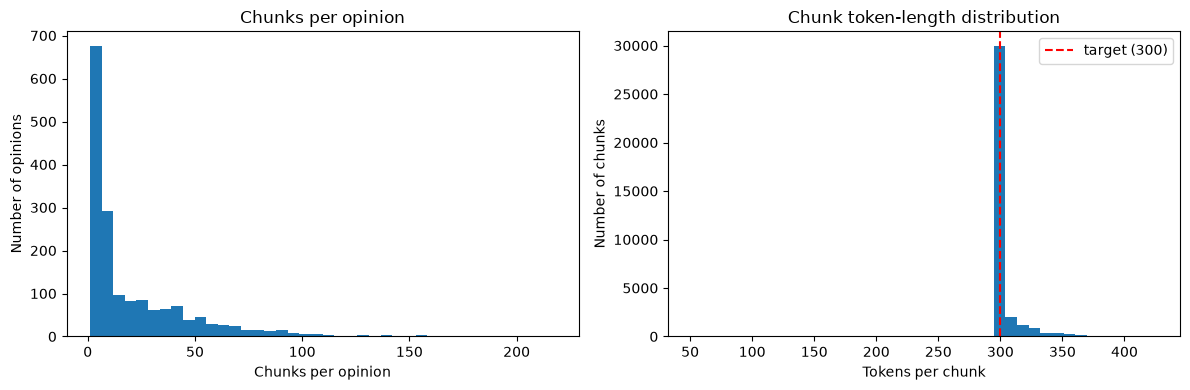

Token length — median: 300, p90: 312, max: 426
(Chunks noticeably above the 300 target are ones where citation-boundary snapping pushed the cutoff further out — expected, not a bug.)


In [3]:
per_opinion = chunks_df.groupby("opinion_id").size()
print("Chunks per opinion:")
print(per_opinion.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(per_opinion, bins=40)
axes[0].set_xlabel("Chunks per opinion")
axes[0].set_ylabel("Number of opinions")
axes[0].set_title("Chunks per opinion")

axes[1].hist(chunks_df["token_len"], bins=40)
axes[1].axvline(config.CHUNK_TOKEN_SIZE, color="red", linestyle="--", label=f"target ({config.CHUNK_TOKEN_SIZE})")
axes[1].set_xlabel("Tokens per chunk")
axes[1].set_ylabel("Number of chunks")
axes[1].set_title("Chunk token-length distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Token length — median: {chunks_df['token_len'].median():.0f}, "
      f"p90: {chunks_df['token_len'].quantile(0.9):.0f}, max: {chunks_df['token_len'].max()}")
print("(Chunks noticeably above the 300 target are ones where citation-boundary "
      "snapping pushed the cutoff further out — expected, not a bug.)")

## 3. Visualizing the overlap between consecutive chunks

Picking one real opinion with several chunks and looking at exactly where
consecutive chunks overlap.

In [4]:
example_opinion_id = per_opinion[per_opinion >= 4].index[0]
example_chunks = chunks_df[chunks_df["opinion_id"] == example_opinion_id].sort_values("chunk_id",
    key=lambda s: s.str.split("_").str[-1].astype(int)).reset_index(drop=True)

print(f"Case: {example_chunks.iloc[0]['case_name']}  ({len(example_chunks)} chunks)\n")
for i, row in example_chunks.iterrows():
    start, end = row["char_span"]
    print(f"  chunk {i}: chars [{start:6d}, {end:6d})  ({row['token_len']} tokens)")

Case: Moriah Zeigler v. County of San Luis Obispo  (7 chunks)

  chunk 0: chars [     0,   1021)  (300 tokens)
  chunk 1: chars [   821,   1992)  (300 tokens)
  chunk 2: chars [  1770,   2975)  (300 tokens)
  chunk 3: chars [  2715,   3962)  (300 tokens)
  chunk 4: chars [  3800,   5032)  (300 tokens)
  chunk 5: chars [  4795,   6120)  (300 tokens)
  chunk 6: chars [  5901,   7144)  (300 tokens)


In [5]:
# Show the literal overlapping text between chunk 0 and chunk 1.
c0, c1 = example_chunks.iloc[0], example_chunks.iloc[1]
overlap_start, overlap_end = c1["char_span"][0], c0["char_span"][1]
overlap_chars = overlap_end - overlap_start

print(f"Chunk 0 spans chars [{c0['char_span'][0]}, {c0['char_span'][1]})")
print(f"Chunk 1 spans chars [{c1['char_span'][0]}, {c1['char_span'][1]})")
print(f"Overlap region: chars [{overlap_start}, {overlap_end})  =  {overlap_chars} characters\n")

print("--- End of chunk 0 ---")
print(repr(c0["text"][-250:]))
print()
print("--- Start of chunk 1 (should visibly repeat the tail of chunk 0 above) ---")
print(repr(c1["text"][:250]))

Chunk 0 spans chars [0, 1021)
Chunk 1 spans chars [821, 1992)
Overlap region: chars [821, 1021)  =  200 characters

--- End of chunk 0 ---
'position is not appropriate for publication and is not precedent except as provided by Ninth Circuit Rule 36-3. ** The panel unanimously concludes this case is suitable for decision without oral argument. See Fed. R. App. P. 34(a)(2). Before: WARDLAW'

--- Start of chunk 1 (should visibly repeat the tail of chunk 0 above) ---
' not precedent except as provided by Ninth Circuit Rule 36-3. ** The panel unanimously concludes this case is suitable for decision without oral argument. See Fed. R. App. P. 34(a)(2). Before: WARDLAW, CHRISTEN, and BENNETT, Circuit Judges. Moriah Ze'


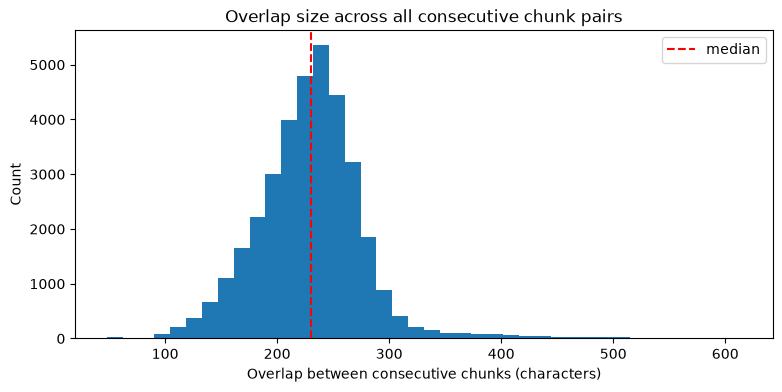

Median overlap: 230 characters (target was 50 tokens ≈ 200-250 characters for legal text)


In [6]:
# Overlap size across the whole corpus, in characters, for every consecutive chunk pair.
overlap_tokens = []
for opinion_id, group in chunks_df.groupby("opinion_id"):
    group = group.sort_values("chunk_id", key=lambda s: s.str.split("_").str[-1].astype(int))
    spans = list(group["char_span"])
    for (s0, e0), (s1, e1) in zip(spans, spans[1:]):
        overlap_tokens.append(max(0, e0 - s1))

fig, ax = plt.subplots()
ax.hist(overlap_tokens, bins=40)
ax.axvline(statistics.median(overlap_tokens), color="red", linestyle="--", label="median")
ax.set_xlabel("Overlap between consecutive chunks (characters)")
ax.set_ylabel("Count")
ax.set_title("Overlap size across all consecutive chunk pairs")
ax.legend()
plt.show()
print(f"Median overlap: {statistics.median(overlap_tokens):.0f} characters "
      f"(target was {config.CHUNK_TOKEN_OVERLAP} tokens \u2248 {config.CHUNK_TOKEN_OVERLAP * 4}-{config.CHUNK_TOKEN_OVERLAP * 5} characters for legal text)")

## 4. What actually gets embedded: citation placeholders

`text` (shown to humans/LLM) vs `embedding_text` (what's actually sent to
the embedding model) — find a chunk with a citation in it to see the swap.

In [7]:
with_citation = chunks_df[chunks_df["text"] != chunks_df["embedding_text"]].iloc[0]
print("--- text (real citations, shown to reader) ---")
print(with_citation["text"][:600])
print()
print("--- embedding_text (citations replaced, this is what gets embedded) ---")
print(with_citation["embedding_text"][:600])

--- text (real citations, shown to reader) ---
 district court’s denial of their motion for summary judgment based on qualified immunity. As to Jurgensen, we affirm in part and reverse in part the district court’s decision. As to Quintana, we reverse the district court’s decision. Government officials are entitled to qualified immunity unless (1) the facts taken most favorably to the party alleging injury show that the official violated a constitutional right, and (2) that constitutional right was clearly established at the time of the alleged injury such that a reasonable official would understand his actions violated the law. Pearson v. 

--- embedding_text (citations replaced, this is what gets embedded) ---
 district court’s denial of their motion for summary judgment based on qualified immunity. As to Jurgensen, we affirm in part and reverse in part the district court’s decision. As to Quintana, we reverse the district court’s decision. Government officials are entitled to qualifi

## 5. The embeddings themselves

Pulling the actual vectors back out of Chroma.

In [8]:
chroma_client = chromadb.PersistentClient(path=str(config.CHROMA_DIR))
collection = chroma_client.get_collection("opinions")
print(f"Collection 'opinions': {collection.count()} vectors")

# Chroma's SQLite backend errors on "too many SQL variables" if you try to
# pull everything (embeddings included) in one .get() call at this volume —
# page through it instead.
ids, embeddings_list, metadatas = [], [], []
PAGE = 1000
offset = 0
while True:
    page = collection.get(include=["embeddings", "metadatas"], limit=PAGE, offset=offset)
    if not page["ids"]:
        break
    ids.extend(page["ids"])
    embeddings_list.extend(page["embeddings"])
    metadatas.extend(page["metadatas"])
    offset += PAGE

embeddings = np.array(embeddings_list)
id_to_idx = {cid: i for i, cid in enumerate(ids)}

print(f"Embedding matrix shape: {embeddings.shape}  (chunks \u00d7 dimensions)")
norms = np.linalg.norm(embeddings, axis=1)
print(f"Vector norms — min: {norms.min():.4f}, max: {norms.max():.4f}, mean: {norms.mean():.4f}")
print("(text-embedding-3-small returns unit-normalized vectors, so norm \u2248 1.0 for all of them — "
      "meaning cosine similarity and dot product are equivalent here.)")
print()
print("First 10 components of one embedding vector, as a concrete look at what these actually are:")
print(np.round(embeddings[0][:10], 4))

Collection 'opinions': 37081 vectors


Embedding matrix shape: (37081, 1536)  (chunks × dimensions)


Vector norms — min: 0.9993, max: 1.0008, mean: 1.0000
(text-embedding-3-small returns unit-normalized vectors, so norm ≈ 1.0 for all of them — meaning cosine similarity and dot product are equivalent here.)

First 10 components of one embedding vector, as a concrete look at what these actually are:
[-0.0056  0.043   0.0057  0.0458 -0.0204 -0.0228  0.0174  0.0368 -0.047
 -0.043 ]


## 6. Nearest neighbors in embedding space

Pick one chunk, find the chunks whose vectors are closest to it (cosine
similarity = dot product, since vectors are unit-normalized) — this is the
literal mechanism vector search runs at query time, just run here
chunk-to-chunk instead of query-to-chunk.

In [9]:
random.seed(3)
query_idx = random.randrange(len(ids))
query_vec = embeddings[query_idx]
query_meta = metadatas[query_idx]

similarities = embeddings @ query_vec  # dot product with every other vector at once
top_idx = np.argsort(-similarities)[:6]  # top 6, index 0 will be itself

print(f"Anchor chunk: {query_meta['case_name']}  ({query_meta['date_filed']})")
print(f"  {chunks_df.loc[chunks_df['chunk_id'] == ids[query_idx], 'text'].values[0][:250]!r}\n")

print("Nearest neighbors by embedding similarity:")
for i in top_idx[1:]:
    m = metadatas[i]
    text = chunks_df.loc[chunks_df["chunk_id"] == ids[i], "text"].values[0]
    print(f"  sim={similarities[i]:.3f}  {m['case_name']}  ({m['date_filed']})")
    print(f"    {text[:200]!r}")

Anchor chunk: Price v. Sery  (2008-01-22)


  ' a rea- sonable person could side with the plaintiff’s interpretation of events, the issue must survive for trial. We conclude that there is a genuine issue of material fact as to whether the City’s interpretation of the differing phrases in G.O. § 1'

Nearest neighbors by embedding similarity:
  sim=0.876  Price v. Sery  (2008-01-22)
    ' issue as to any material fact and that the moving party is entitled to a judg- ment as a matter of law.” Fed. R. Civ.P. 56(c). PRICE v. SERY 789 Price also made allegations concerning the City’s trai'
  sim=0.864  Price v. Sery  (2008-01-22)
    ' record, such as the PARC report, could support Price’s claims. 802 PRICE v. SERY [10] The district court was unwilling to give the Streed Declaration sufficient weight to survive summary judgment onc'
  sim=0.834  Price v. Sery  (2008-01-22)
    ' the inquiry is “reasonableness,” which does not admit of an “easy-to-apply legal test.” 127 S. Ct. at 1777-78. The City’s policy requires that an officer have

## 7. A 2D map of the embedding space

Projecting a random sample of chunks down to 2 dimensions with PCA (via
plain SVD — no extra dependency needed) just to see if there's visible
structure. Don't over-read this: PCA keeps only the two directions of
largest variance out of 1536, so real semantic clusters can easily get
flattened together here even if they're well-separated in full dimension.

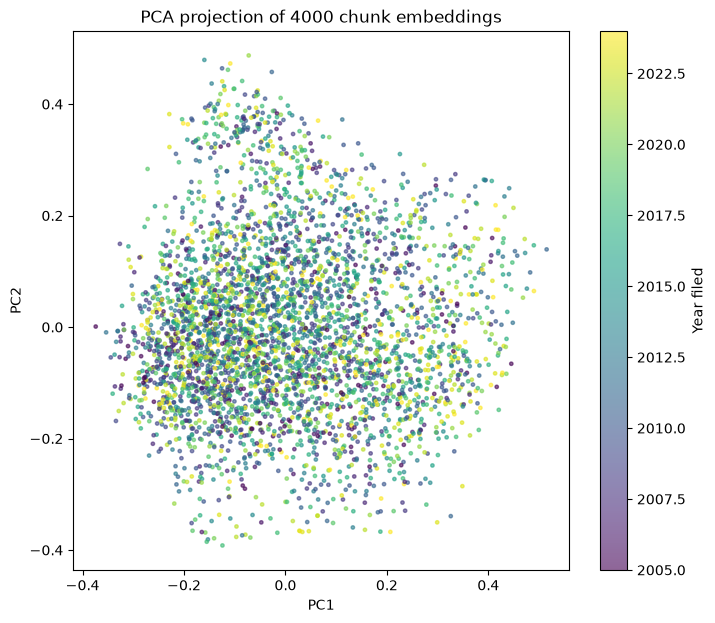

These 2 components explain 9.2% of total variance (the rest lives in the other 1534 dimensions).


In [10]:
sample_n = min(4000, len(ids))
sample_idx = np.random.RandomState(0).choice(len(ids), size=sample_n, replace=False)
sample_emb = embeddings[sample_idx]

centered = sample_emb - sample_emb.mean(axis=0)
U, S, Vt = np.linalg.svd(centered, full_matrices=False)
coords_2d = U[:, :2] * S[:2]

years = pd.to_datetime([metadatas[i]["date_filed"] for i in sample_idx], errors="coerce").year

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(coords_2d[:, 0], coords_2d[:, 1], c=years, cmap="viridis", s=6, alpha=0.6)
plt.colorbar(sc, label="Year filed")
ax.set_title(f"PCA projection of {sample_n} chunk embeddings")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

var_explained = (S[:2] ** 2).sum() / (S ** 2).sum()
print(f"These 2 components explain {var_explained:.1%} of total variance "
      f"(the rest lives in the other {embeddings.shape[1] - 2} dimensions).")

## 8. Live query demo

Embeds one real question through the OpenAI API (a single call, trivial
cost) and shows the top matches — the same mechanism `retrieval/hybrid_retrieve.py`
uses, just the vector-search half only, without the graph-expansion step.

In [11]:
from openai import OpenAI

if config.OPENAI_API_KEY:
    client = OpenAI(api_key=config.OPENAI_API_KEY)
    query = "Can police use a taser on a suspect who is already handcuffed and restrained?"
    query_vec = np.array(client.embeddings.create(model=config.EMBEDDING_MODEL, input=[query]).data[0].embedding)

    sims = embeddings @ query_vec
    top_idx = np.argsort(-sims)[:5]

    print(f"Query: {query}\n")
    for i in top_idx:
        m = metadatas[i]
        text = chunks_df.loc[chunks_df["chunk_id"] == ids[i], "text"].values[0]
        print(f"sim={sims[i]:.3f}  {m['case_name']}  ({m['date_filed']})")
        print(f"  {text[:200]!r}\n")
else:
    print("OPENAI_API_KEY not set — skipping live query demo.")

Query: Can police use a taser on a suspect who is already handcuffed and restrained?

sim=0.619  Tucker v. Las Vegas Metropolitan Police Department  (2012-03-02)
  ' that a suspect, once handcuffed, no longer poses any danger to arresting officers. See George T. Payton & Michael Amaral, Patrol Operations and Enforcement Tactics 242 (11th ed. 2004) (“Even when cuf'

sim=0.611  Mattos v. Agarano  (2011-10-17)
  ' is no fun either). These methods are also distasteful to officers, who can deploy such close-range tactics only by stepping in harm’s way. The Taser is a safe alternative: It’s effective at a range o'

sim=0.598  Kyle Cardenas v. Josiah Saladen  (2023-03-02)
  'ous use of a taser, tasing a suspect who was already subdued, or tasing a suspect who was not resisting arrest or was at most simply noncompliant with an order. See, e.g., Fils v. City of Aventura, 64'

sim=0.597  Kyle Cardenas v. Josiah Saladen  (2023-03-02)
  ' in rapid succession. 661 F.3d 433, 436–37, 445–46 (9th Cir.

## Summary

- **37,081 chunks** from 1,696 opinions, ~300 tokens each (median close to
  target; the right tail is citation-boundary snapping doing its job, not
  noise).
- **Overlap** between consecutive chunks is real and visible — confirmed by
  literally printing the shared text region, not just trusting the numbers.
- **Citation placeholders**: confirmed `embedding_text` really does swap out
  citation strings for `[CITATION]` before embedding, while the original
  `text` (with real citations) is what's stored for display.
- **Embeddings**: 1536-dimensional, unit-normalized (so cosine similarity =
  dot product), and the nearest-neighbor check shows genuinely
  semantically-related chunks clustering together — not just noise.
- **PCA plot** is a rough sanity check, not a rigorous analysis — 2 of 1536
  dimensions rarely captures much; treat any visible structure as
  suggestive, not conclusive.

Next step: generation (module 4) — turning retrieved chunks into an actual
answer with inline citations.